<a href="https://colab.research.google.com/github/luqmarqs/especializacao-data-science/blob/main/CNN_CIFAR_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Imports
This cell imports the necessary libraries:
- `torch`: The main PyTorch library.
- `torch.nn`: Used to build neural network layers.
- `torch.optim`: Contains optimization algorithms like Adam.
- `torchvision`: Provides access to popular datasets, model architectures, and image transformations.
- `torchvision.transforms`: Used for common image transformations.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

### Device Configuration
This cell sets up the device (GPU or CPU) for training and inference. It checks if a CUDA-enabled GPU is available and, if so, uses it; otherwise, it falls back to the CPU. This ensures that the computations are performed on the most efficient hardware available.

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


### Define Classes
This cell defines a tuple named `classes` containing the names of the 10 categories present in the CIFAR-10 dataset, translated to Portuguese. These labels will be used for interpreting the model's predictions.

In [3]:
classes = (
    "avião", "carro", "pássaro", "gato", "veado",
    "cachorro", "sapo", "cavalo", "navio", "caminhão"
)

### Data Loading and Transformation
This cell handles the preparation of the CIFAR-10 dataset:
- **`transform`**: Defines a sequence of image transformations:
  - `transforms.ToTensor()`: Converts PIL images or NumPy arrays to PyTorch tensors and scales pixel values from `[0, 255]` to `[0.0, 1.0]`.
  - `transforms.Normalize()`: Normalizes the tensor image with mean and standard deviation for each channel. This helps in stabilizing and accelerating the training process.
- **`trainset` and `testset`**: Loads the CIFAR-10 dataset for training and testing, respectively. The data is downloaded to a `./data` directory if not already present.
- **`trainloader` and `testloader`**: Creates data loaders that provide an iterable over the dataset, facilitating batch processing and shuffling during training.

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=64,
    shuffle=True
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=64,
    shuffle=False
)

100%|██████████| 170M/170M [00:15<00:00, 10.9MB/s]


### Define the CNN Model
This cell defines the `SimpleCNN` class, which is a convolutional neural network (CNN) model:
- **`__init__`**: Initializes the layers of the network.
  - **`features`**: A `nn.Sequential` block consisting of three convolutional layers, each followed by a ReLU activation and a MaxPool2d layer for feature extraction.
    - `nn.Conv2d`: Applies 2D convolution over an input signal composed of several input planes.
    - `nn.ReLU`: Rectified Linear Unit activation function.
    - `nn.MaxPool2d`: Applies 2D max pooling operation.
  - **`classifier`**: A `nn.Sequential` block for classification.
    - `nn.Flatten()`: Flattens the output of the convolutional layers into a 1D vector.
    - `nn.Linear`: Applies a linear transformation (fully connected layer).
- **`forward`**: Defines the forward pass of the model, specifying how data flows through the layers.
- The model is then instantiated and moved to the specified `device` (GPU or CPU).

In [5]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


### Loss Function and Optimizer
This cell configures the training components:
- **`criterion`**: `nn.CrossEntropyLoss()` is chosen as the loss function. This is commonly used for multi-class classification problems, especially when the output of the network is raw unnormalized scores (logits).
- **`optimizer`**: `optim.Adam()` is selected as the optimizer. Adam is an adaptive learning rate optimization algorithm that is computationally efficient and has shown good performance in various deep learning tasks. It takes `model.parameters()` to optimize all learnable parameters of the CNN and sets a learning rate (`lr`) of 0.001.

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### Model Training
This cell implements the training loop for the CNN model:
- **`epochs = 10`**: The number of full passes over the training dataset.
- **`model.train()`**: Sets the model to training mode. This is important for layers like BatchNorm and Dropout, which behave differently during training and evaluation.
- The outer loop iterates through each epoch.
- The inner loop iterates through batches of `images` and `labels` from the `trainloader`.
- **`optimizer.zero_grad()`**: Clears the gradients of all optimized `torch.Tensor`s. This is crucial because PyTorch accumulates gradients by default.
- **`outputs = model(images)`**: Performs a forward pass to get the model's predictions.
- **`loss = criterion(outputs, labels)`**: Calculates the loss between the predicted `outputs` and the true `labels`.
- **`loss.backward()`**: Computes the gradient of the loss with respect to the model's parameters.
- **`optimizer.step()`**: Updates the model's parameters using the calculated gradients and the chosen optimization algorithm.
- `running_loss` accumulates the loss for each batch to report the average loss per epoch.

In [7]:
epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in trainloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Época {epoch+1}/{epochs} - Loss: {running_loss/len(trainloader):.4f}")

Época 1/10 - Loss: 1.3755
Época 2/10 - Loss: 0.9510
Época 3/10 - Loss: 0.7685
Época 4/10 - Loss: 0.6411
Época 5/10 - Loss: 0.5312
Época 6/10 - Loss: 0.4434
Época 7/10 - Loss: 0.3538
Época 8/10 - Loss: 0.2791
Época 9/10 - Loss: 0.2169
Época 10/10 - Loss: 0.1669


### Model Evaluation
This cell evaluates the trained model's performance on the test dataset:
- **`model.eval()`**: Sets the model to evaluation mode. This disables features like Dropout and BatchNorm updates, which are only relevant during training.
- **`torch.no_grad()`**: Disables gradient calculation. This is important during inference as it reduces memory consumption and speeds up computation.
- The loop iterates through batches from the `testloader`.
- **`outputs = model(images)`**: Performs a forward pass on test images.
- **`_, predicted = torch.max(outputs, 1)`**: Retrieves the class with the highest probability from the model's output (the prediction).
- It then compares `predicted` labels with `labels` to count `correct` predictions and `total` samples.
- Finally, it calculates and prints the overall `accuracy` of the model on the test set.

In [8]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Acurácia no teste: {accuracy:.2f}%")

Acurácia no teste: 74.95%


### Visualize Predictions
This cell visualizes a few test images and their predicted labels:
- **`imshow(img)`**: A helper function to display a tensor image. It denormalizes the image and converts it to a NumPy array for `matplotlib`.
- It gets a batch of images and labels from the `testloader`.
- **`torchvision.utils.make_grid(images[:8])`**: Creates a grid of the first 8 images in the batch for display.
- It then performs a forward pass on these images using the trained model to get predictions.
- Finally, it prints the actual (real) labels and the model's predicted labels for these 8 images, allowing for a qualitative assessment of the model's performance.

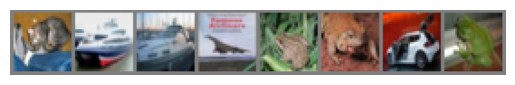

Real:      ['gato', 'navio', 'navio', 'avião', 'sapo', 'sapo', 'carro', 'sapo']
Previsto:  ['cachorro', 'carro', 'caminhão', 'avião', 'sapo', 'sapo', 'gato', 'sapo']


In [9]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis("off")
    plt.show()

dataiter = iter(testloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images[:8]))

images_gpu = images[:8].to(device)
outputs = model(images_gpu)
_, predicted = torch.max(outputs, 1)

print("Real:     ", [classes[labels[i]] for i in range(8)])
print("Previsto: ", [classes[predicted[i]] for i in range(8)])

### Save Model State
This cell saves the trained model's parameters (its `state_dict`) to a file named `cnn_cifar10.pth`. This allows you to reload the model later without retraining it, making it convenient for deployment or further analysis.

In [10]:
torch.save(model.state_dict(), "cnn_cifar10.pth")

### Load Model State
This cell demonstrates how to load a previously saved model:
- It first re-instantiates the `SimpleCNN` model.
- **`torch.load("cnn_cifar10.pth", map_location=device)`**: Loads the saved `state_dict` from the specified file. `map_location=device` ensures that the model is loaded onto the correct device (GPU or CPU).
- **`model.load_state_dict(...)`**: Loads the saved parameters into the newly created model instance.
- **`model.eval()`**: Sets the loaded model back to evaluation mode, preparing it for inference.

In [11]:
model = SimpleCNN().to(device)
model.load_state_dict(torch.load("cnn_cifar10.pth", map_location=device))
model.eval()

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)